# Specific-resolution evaluation figures

This notebook reproduces the `Evaluation` views from `detector2026` for three YOLOv11n runs:

- `yolov11n_specificres`: amplitude only
- `yolov11n_phasis_specificres`: amplitude + phase on 2 channels
- `yolov11n_complex_specificres`: real + imaginary on 2 channels

It recreates:

- mAP vs FLOPs / Params
- best recall vs SNR
- mAP vs epochs
- loss vs epochs
- recall vs epochs
- row-normalized confusion matrices for each SNR band

Run this notebook with the `detector2026` Python environment declared in `environment.yml`.


In [12]:
from __future__ import annotations

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [13]:
DEFAULT_PROJECT_ROOT = Path("/Users/tailleesarah/Documents/thèse/icml/detector2026")
CANDIDATE_ROOTS = [Path.cwd(), Path.cwd().parent, DEFAULT_PROJECT_ROOT]

PROJECT_ROOT = None
for candidate in CANDIDATE_ROOTS:
    candidate = candidate.resolve()
    if (candidate / "runs" / "examples_of_training").is_dir():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate detector2026 project root.")

RUNS_ROOT = PROJECT_ROOT / "runs" / "examples_of_training"
OUTPUT_DIR = PROJECT_ROOT / "icml_reviewer_responses" / "generated_specificres_eval_figures"
SAVE_FIGURES = False

RUN_SPECS = [
    {
        "label": "Amplitude only",
        "run_name": "yolov11n_specificres",
        "representation": "amplitude",
    },
    {
        "label": "Amplitude + phase",
        "run_name": "yolov11n_phasis_specificres",
        "representation": "amplitude + phase (2ch)",
    },
    {
        "label": "Real + imaginary",
        "run_name": "yolov11n_complex_specificres",
        "representation": "real + imaginary (2ch)",
    },
]

SNR_BANDS = [
    ("low_snr", "Low SNR"),
    ("medium_snr", "Medium SNR"),
    ("high_snr", "High SNR"),
]

METRIC_LABELS = {
    "train_loss": "Training loss",
    "val_loss": "Validation loss",
    "map50": "mAP50",
    "map50_95": "mAP50:95",
    "avg_recall_low_snr": "Recall low SNR",
    "avg_recall_medium_snr": "Recall medium SNR",
    "avg_recall_high_snr": "Recall high SNR",
}

COLOR_BY_LABEL = {
    "Amplitude only": "#3f566b",
    "Amplitude + phase": "#8b4c18",
    "Real + imaginary": "#c8742f",
}

MARKER_BY_METRIC = {"map50_95": "o", "map50": "s"}
CONFUSION_LABELS = [f"c{i}" for i in range(20)] + ["bg"]
ORANGE_CMAP = sns.light_palette("#c8742f", as_cmap=True)

if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT


PosixPath('/Users/tailleesarah/Documents/thèse/icml/detector2026')

In [14]:
METRIC_COLUMNS = [
    "train_loss",
    "val_loss",
    "loss_box_train",
    "loss_cls_train",
    "loss_dfl_train",
    "loss_box_val",
    "loss_cls_val",
    "loss_dfl_val",
    "map50",
    "map50_95",
    "avg_recall_low_snr",
    "avg_recall_medium_snr",
    "avg_recall_high_snr",
]


def human_number(value: float) -> str:
    value = float(value)
    sign = "-" if value < 0 else ""
    value = abs(value)
    for suffix, scale in (("T", 1e12), ("B", 1e9), ("M", 1e6), ("K", 1e3)):
        if value >= scale:
            return f"{sign}{value / scale:.2f}{suffix}"
    return f"{sign}{value:.0f}"


def metric_formatter(metric_key: str):
    if metric_key in {"map50", "map50_95", "avg_recall_low_snr", "avg_recall_medium_snr", "avg_recall_high_snr"}:
        return FuncFormatter(lambda value, _: f"{value:.2f}")
    return FuncFormatter(lambda value, _: f"{value:.0f}" if abs(value) >= 100 else f"{value:.2f}")


def resolve_metrics_json_path(run_dir: Path, row: pd.Series) -> Path:
    candidates = []
    raw_path = row.get("metrics_json_path")
    if isinstance(raw_path, str) and raw_path.strip():
        candidate = Path(raw_path)
        if candidate.is_absolute():
            candidates.append(candidate)
            candidates.append(run_dir / "metrics" / candidate.name)
        else:
            candidates.append((run_dir / candidate).resolve())
            candidates.append(run_dir / "metrics" / candidate.name)

    epoch = int(row["epoch"])
    candidates.append(run_dir / "metrics" / f"metrics_epoch_{epoch:03d}.json")

    seen = set()
    for path in candidates:
        if path in seen:
            continue
        seen.add(path)
        if path.is_file():
            return path

    raise FileNotFoundError(f"Could not resolve metrics JSON for {run_dir.name} epoch {epoch}.")


def load_run(spec: dict) -> dict:
    run_dir = RUNS_ROOT / spec["run_name"]
    if not run_dir.is_dir():
        raise FileNotFoundError(f"Missing run directory: {run_dir}")

    train_log = pd.read_csv(run_dir / "train_log.csv")
    train_log["epoch"] = train_log["epoch"].astype(int)
    for column in METRIC_COLUMNS:
        train_log[column] = pd.to_numeric(train_log[column], errors="coerce")

    best_checkpoint_row = train_log.loc[train_log["map50_95"].idxmax()].copy()
    best_recall_row = train_log.loc[train_log["avg_recall_low_snr"].idxmax()].copy()
    best_val_loss_row = train_log.loc[train_log["val_loss"].idxmin()].copy()

    best_checkpoint_metrics_path = resolve_metrics_json_path(run_dir, best_checkpoint_row)
    best_recall_metrics_path = resolve_metrics_json_path(run_dir, best_recall_row)

    best_checkpoint_payload = json.loads(best_checkpoint_metrics_path.read_text())
    best_recall_payload = json.loads(best_recall_metrics_path.read_text())
    model_info = best_checkpoint_payload.get("model_info", {})

    return {
        **spec,
        "run_dir": run_dir,
        "train_log": train_log,
        "epochs_completed": int(train_log["epoch"].max()),
        "best_checkpoint_row": best_checkpoint_row,
        "best_recall_row": best_recall_row,
        "best_val_loss_row": best_val_loss_row,
        "best_checkpoint_epoch": int(best_checkpoint_row["epoch"]),
        "best_recall_epoch": int(best_recall_row["epoch"]),
        "best_val_loss_epoch": int(best_val_loss_row["epoch"]),
        "best_checkpoint_payload": best_checkpoint_payload,
        "best_recall_payload": best_recall_payload,
        "params": float(model_info.get("params", float("nan"))),
        "flops": float(model_info.get("flops", float("nan"))),
    }


def build_summary_table(runs: list[dict]) -> pd.DataFrame:
    rows = []
    for run in runs:
        checkpoint = run["best_checkpoint_row"]
        rows.append({
            "Label": run["label"],
            "Representation": run["representation"],
            "Run": run["run_name"],
            "Epochs": run["epochs_completed"],
            "Best checkpoint epoch": run["best_checkpoint_epoch"],
            "Best recall epoch": run["best_recall_epoch"],
            "Best val-loss epoch": run["best_val_loss_epoch"],
            "mAP50:95": checkpoint["map50_95"],
            "mAP50": checkpoint["map50"],
            "Recall low SNR": checkpoint["avg_recall_low_snr"],
            "Recall medium SNR": checkpoint["avg_recall_medium_snr"],
            "Recall high SNR": checkpoint["avg_recall_high_snr"],
            "Params": run["params"],
            "FLOPs": run["flops"],
        })
    return pd.DataFrame(rows)


def maybe_save(fig: plt.Figure, stem: str) -> None:
    if not SAVE_FIGURES:
        return
    fig.savefig(OUTPUT_DIR / f"{stem}.png", bbox_inches="tight")


def normalize_confusion_matrix(matrix: np.ndarray, normalization: str) -> np.ndarray:
    matrix = np.asarray(matrix, dtype=float)
    if normalization == "row":
        sums = matrix.sum(axis=1, keepdims=True)
        return np.divide(matrix, sums, out=np.zeros_like(matrix), where=sums > 0)
    if normalization == "column":
        sums = matrix.sum(axis=0, keepdims=True)
        return np.divide(matrix, sums, out=np.zeros_like(matrix), where=sums > 0)
    return matrix


In [15]:
RUNS = [load_run(spec) for spec in RUN_SPECS]

summary_df = build_summary_table(RUNS)
display(summary_df.style.format({
    "mAP50:95": "{:.4f}",
    "mAP50": "{:.4f}",
    "Recall low SNR": "{:.4f}",
    "Recall medium SNR": "{:.4f}",
    "Recall high SNR": "{:.4f}",
    "Params": lambda value: human_number(value),
    "FLOPs": lambda value: human_number(value),
}))

print(f"Project root: {PROJECT_ROOT}")
print(f"Save figures: {SAVE_FIGURES}")
if SAVE_FIGURES:
    print(f"Output dir: {OUTPUT_DIR}")


,Label,Representation,Run,Epochs,Best checkpoint epoch,Best recall epoch,Best val-loss epoch,mAP50:95,mAP50,Recall low SNR,Recall medium SNR,Recall high SNR,Params,FLOPs
0,Amplitude only,amplitude,yolov11n_specificres,39,36,23,39,0.3396,0.3999,0.4420,0.5599,0.6327,2.88M,629.64M
1,Amplitude + phase,amplitude + phase (2ch),yolov11n_phasis_specificres,35,21,26,34,0.3127,0.3833,0.4369,0.5551,0.6305,2.88M,632.00M
2,Real + imaginary,real + imaginary (2ch),yolov11n_complex_specificres,55,40,29,46,0.3077,0.3671,0.4308,0.5475,0.6239,2.88M,632.00M


Project root: /Users/tailleesarah/Documents/thèse/icml/detector2026
Save figures: False


## Plot helpers

The functions below mirror the `Evaluation` page, with the confusion-matrix section restricted to the row-normalized view requested here.


In [16]:
def plot_map_vs_model_cost(runs: list[dict], x_key: str, metric_keys=("map50_95", "map50")) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

    for run in runs:
        x_value = run[x_key]
        for metric_key in metric_keys:
            y_value = float(run["best_checkpoint_row"][metric_key])
            ax.scatter(
                x_value,
                y_value,
                s=180,
                color=COLOR_BY_LABEL[run["label"]],
                marker=MARKER_BY_METRIC[metric_key],
                edgecolor="black",
                linewidth=0.6,
                alpha=0.95,
            )
            ax.annotate(
                f"{run['label']}\n{METRIC_LABELS[metric_key]}",
                (x_value, y_value),
                textcoords="offset points",
                xytext=(8, 8),
                fontsize=10,
            )

    ax.set_title(f"Best checkpoint performance vs {x_key}")
    ax.set_xlabel("FLOPs" if x_key == "flops" else "Parameters")
    ax.set_ylabel("mAP")
    ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: human_number(value)))
    ax.yaxis.set_major_formatter(metric_formatter("map50_95"))
    ax.grid(True, alpha=0.25)

    run_handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=COLOR_BY_LABEL[run["label"]], markeredgecolor="black", markersize=10, label=run["label"])
        for run in runs
    ]
    metric_handles = [
        Line2D([0], [0], marker=MARKER_BY_METRIC[metric_key], color="black", linestyle="", markersize=9, label=METRIC_LABELS[metric_key])
        for metric_key in metric_keys
    ]
    ax.legend(handles=run_handles + metric_handles, loc="best", frameon=True)

    maybe_save(fig, f"scatter_{x_key}")
    return fig


def plot_best_recall_vs_snr(runs: list[dict]) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

    for run in runs:
        recall_payload = run["best_recall_payload"]["recall_snr"]["global"]
        snr_bins = np.asarray(recall_payload["snr_bins"], dtype=float)
        recall = np.asarray(recall_payload["recall"], dtype=float)
        # Some stored recall_snr artifacts contain one more bin edge than recall value.
        count = min(len(snr_bins), len(recall))
        snr_bins = snr_bins[:count]
        recall = recall[:count]
        ax.plot(
            snr_bins,
            recall,
            linewidth=2.6,
            marker="o",
            markersize=4.5,
            color=COLOR_BY_LABEL[run["label"]],
            label=f"{run['label']} (epoch {run['best_recall_epoch']})",
        )

    ax.set_title("Best recall vs SNR")
    ax.set_xlabel("SNR")
    ax.set_ylabel("Recall")
    ax.yaxis.set_major_formatter(metric_formatter("avg_recall_low_snr"))
    ax.legend(loc="best")
    ax.grid(True, alpha=0.25)

    maybe_save(fig, "best_recall_vs_snr")
    return fig


def plot_metric_grid(runs: list[dict], metric_keys: list[str], ncols: int = 2, figsize: tuple[int, int] | None = None, save_stem: str | None = None) -> plt.Figure:
    nplots = len(metric_keys)
    ncols = min(ncols, nplots)
    nrows = math.ceil(nplots / ncols)
    if figsize is None:
        figsize = (7 * ncols, 4.6 * nrows)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True, squeeze=False)
    flat_axes = axes.ravel()

    for ax, metric_key in zip(flat_axes, metric_keys):
        for run in runs:
            curve = run["train_log"][["epoch", metric_key]].dropna()
            ax.plot(
                curve["epoch"],
                curve[metric_key],
                linewidth=2.4,
                color=COLOR_BY_LABEL[run["label"]],
                label=run["label"],
            )
        ax.set_title(METRIC_LABELS[metric_key])
        ax.set_xlabel("Epoch")
        ax.set_ylabel(METRIC_LABELS[metric_key])
        ax.yaxis.set_major_formatter(metric_formatter(metric_key))
        ax.grid(True, alpha=0.25)

    for ax in flat_axes[nplots:]:
        ax.set_visible(False)

    handles, labels = flat_axes[0].get_legend_handles_labels()
    flat_axes[0].legend(handles, labels, loc="best")

    if save_stem is not None:
        maybe_save(fig, save_stem)
    return fig


def plot_single_confusion_grid(runs: list[dict], normalization: str = "row") -> plt.Figure:
    fig, axes = plt.subplots(len(SNR_BANDS), len(runs), figsize=(5.4 * len(runs), 4.8 * len(SNR_BANDS)), constrained_layout=True, squeeze=False)

    for row_index, (snr_key, snr_label) in enumerate(SNR_BANDS):
        for col_index, run in enumerate(runs):
            ax = axes[row_index, col_index]
            matrix = np.asarray(run["best_checkpoint_payload"][f"conf_matrix_{snr_key}"], dtype=float)
            display_matrix = normalize_confusion_matrix(matrix, normalization)
            vmax = 1.0 if normalization != "none" else max(float(display_matrix.max()), 1.0)

            sns.heatmap(
                display_matrix,
                ax=ax,
                cmap=ORANGE_CMAP,
                vmin=0,
                vmax=vmax,
                square=True,
                cbar=(col_index == len(runs) - 1),
                xticklabels=CONFUSION_LABELS,
                yticklabels=CONFUSION_LABELS,
            )
            ax.set_title(f"{run['label']}\n{snr_label} | epoch {run['best_checkpoint_epoch']}")
            ax.set_xlabel("Predicted")
            ax.set_ylabel("Ground truth")
            ax.tick_params(axis="x", labelrotation=90, labelsize=6)
            ax.tick_params(axis="y", labelrotation=0, labelsize=6)

    fig.suptitle(f"Row-normalized confusion matrices ({normalization})", y=1.02, fontsize=18)
    maybe_save(fig, f"confusion_single_{normalization}")
    return fig


## mAP vs model cost


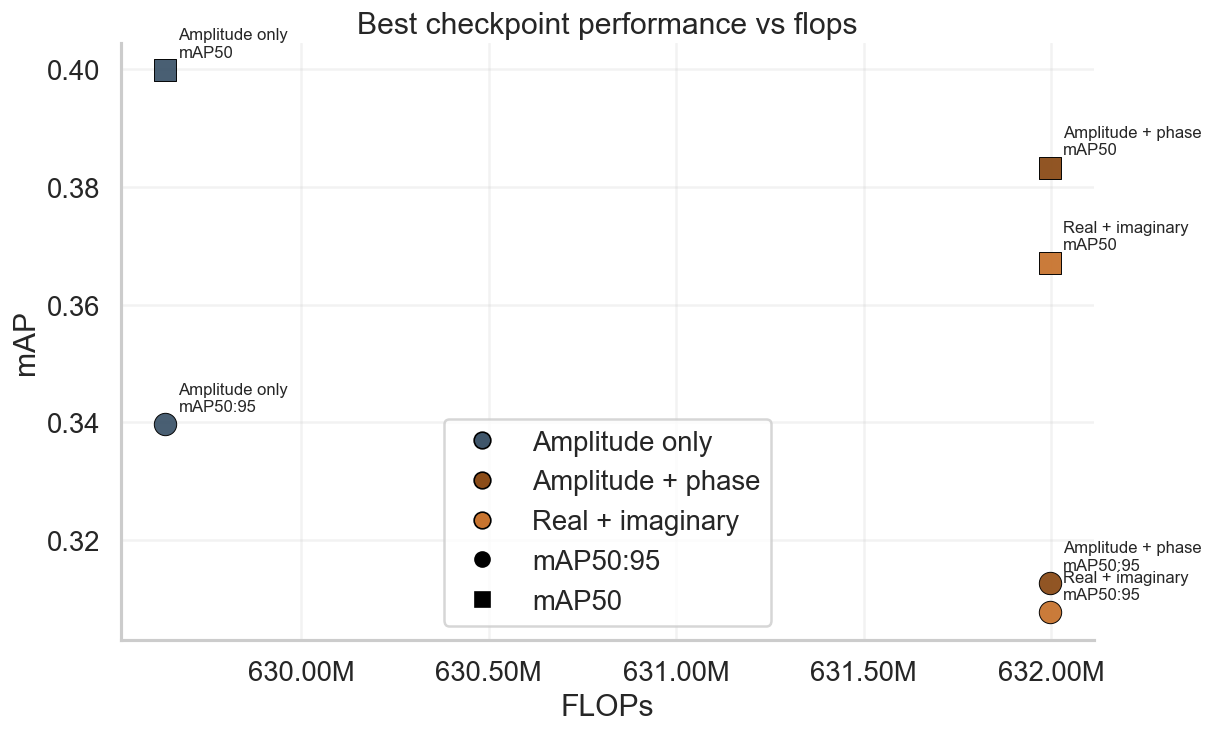

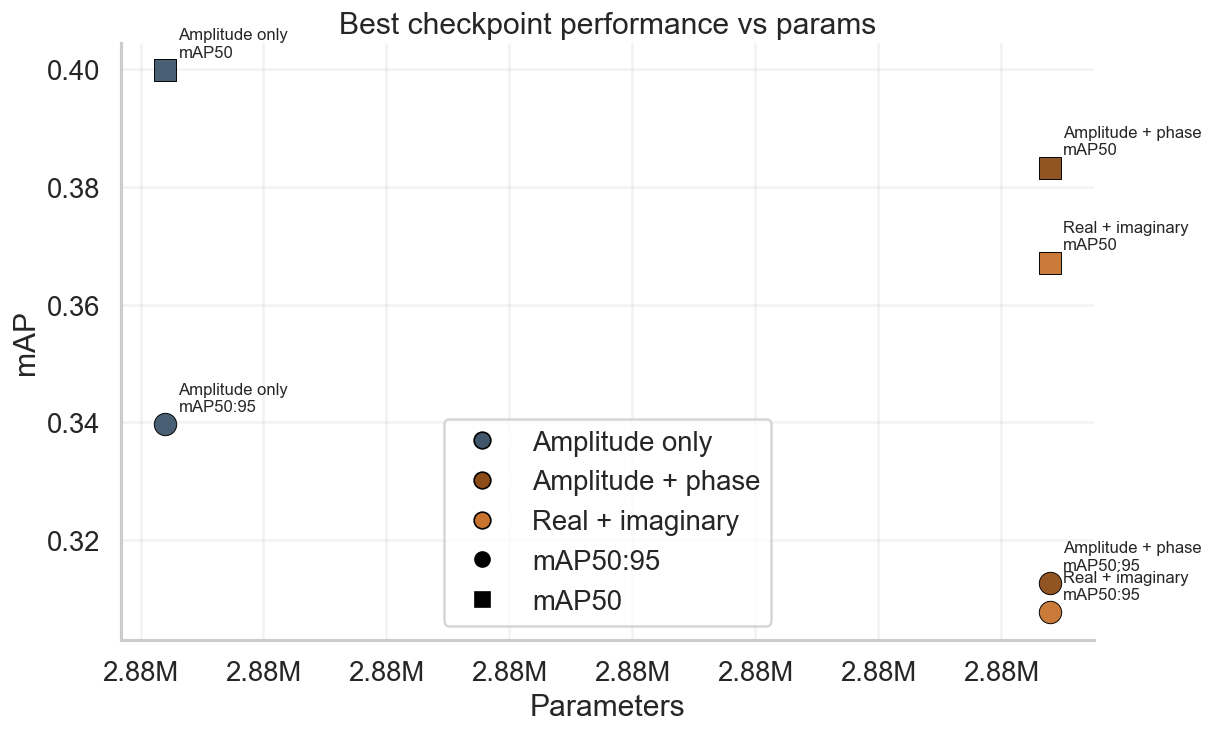

In [17]:
fig = plot_map_vs_model_cost(RUNS, "flops")
plt.show()

fig = plot_map_vs_model_cost(RUNS, "params")
plt.show()


## Best recall vs SNR


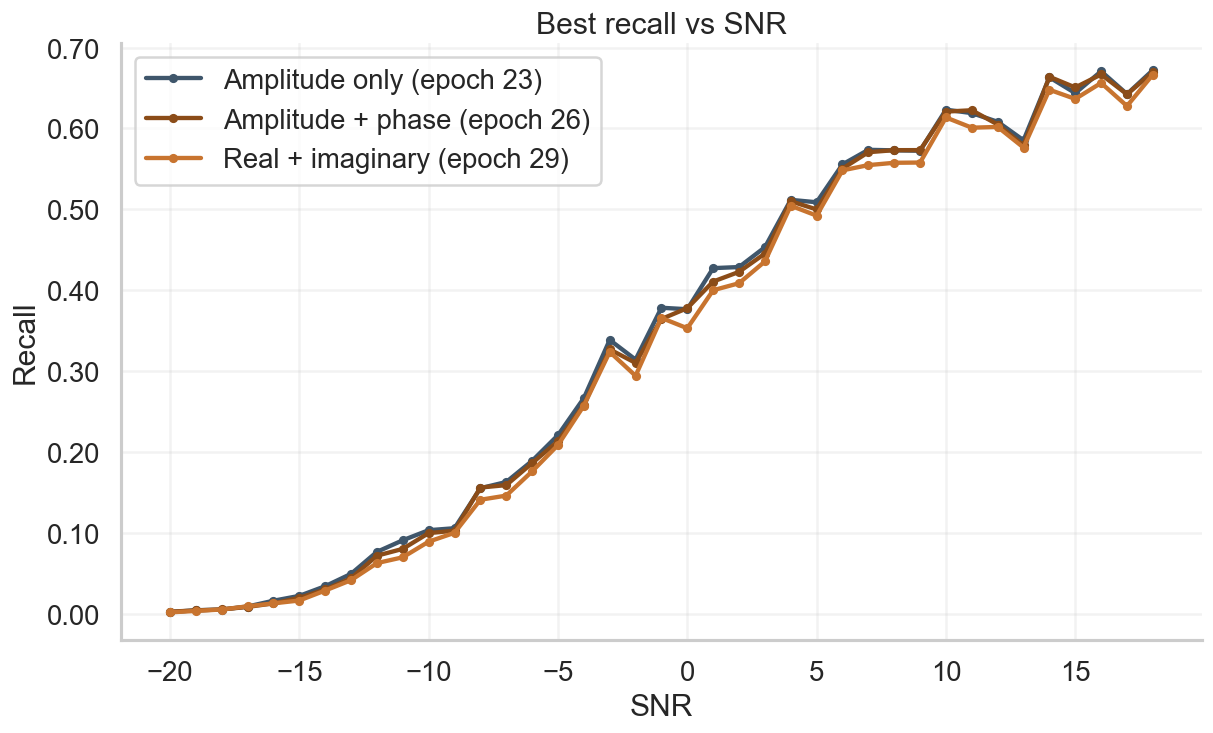

In [18]:
fig = plot_best_recall_vs_snr(RUNS)
plt.show()


## Metric curves vs epochs


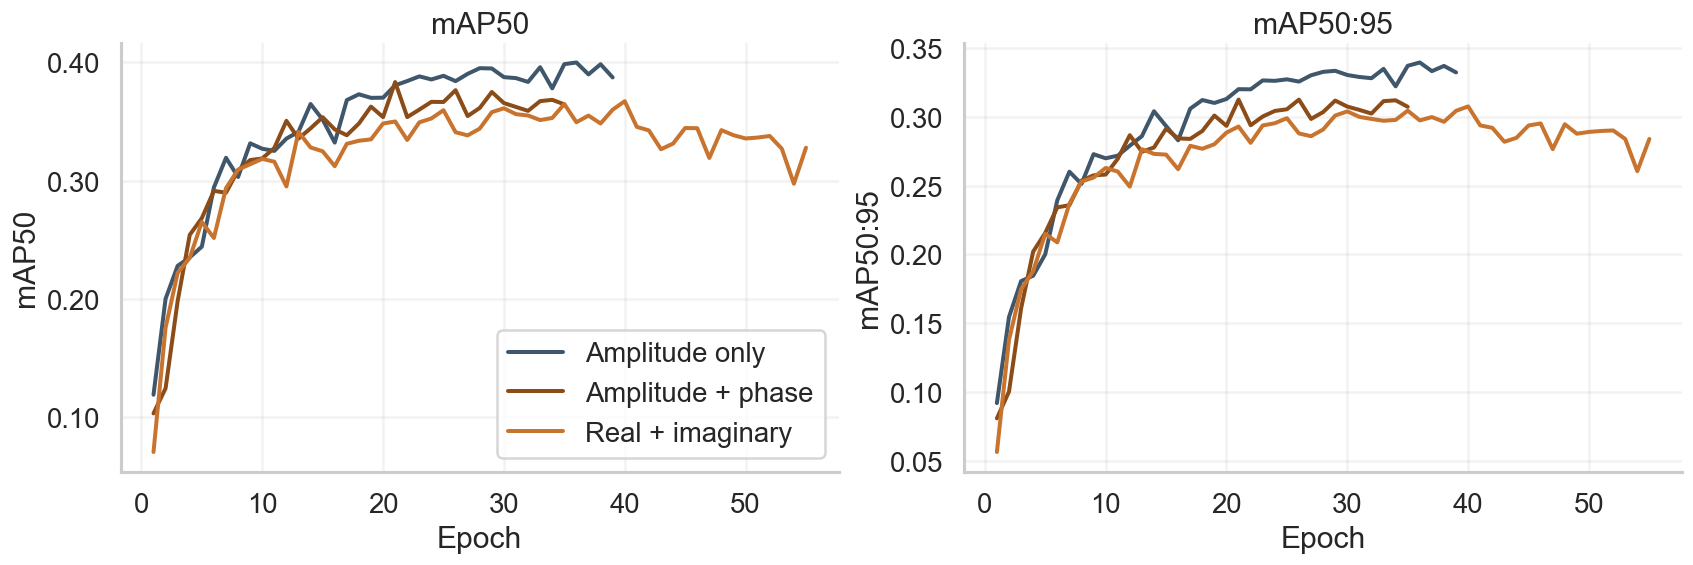

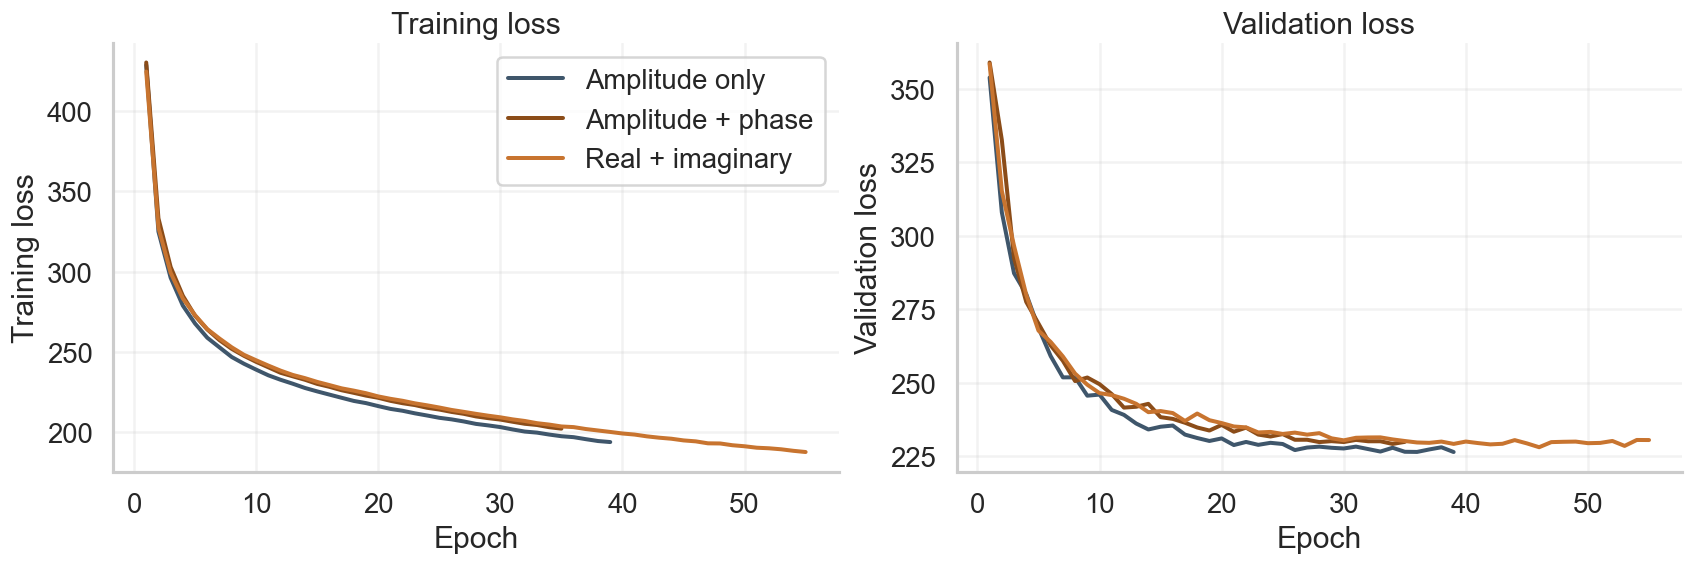

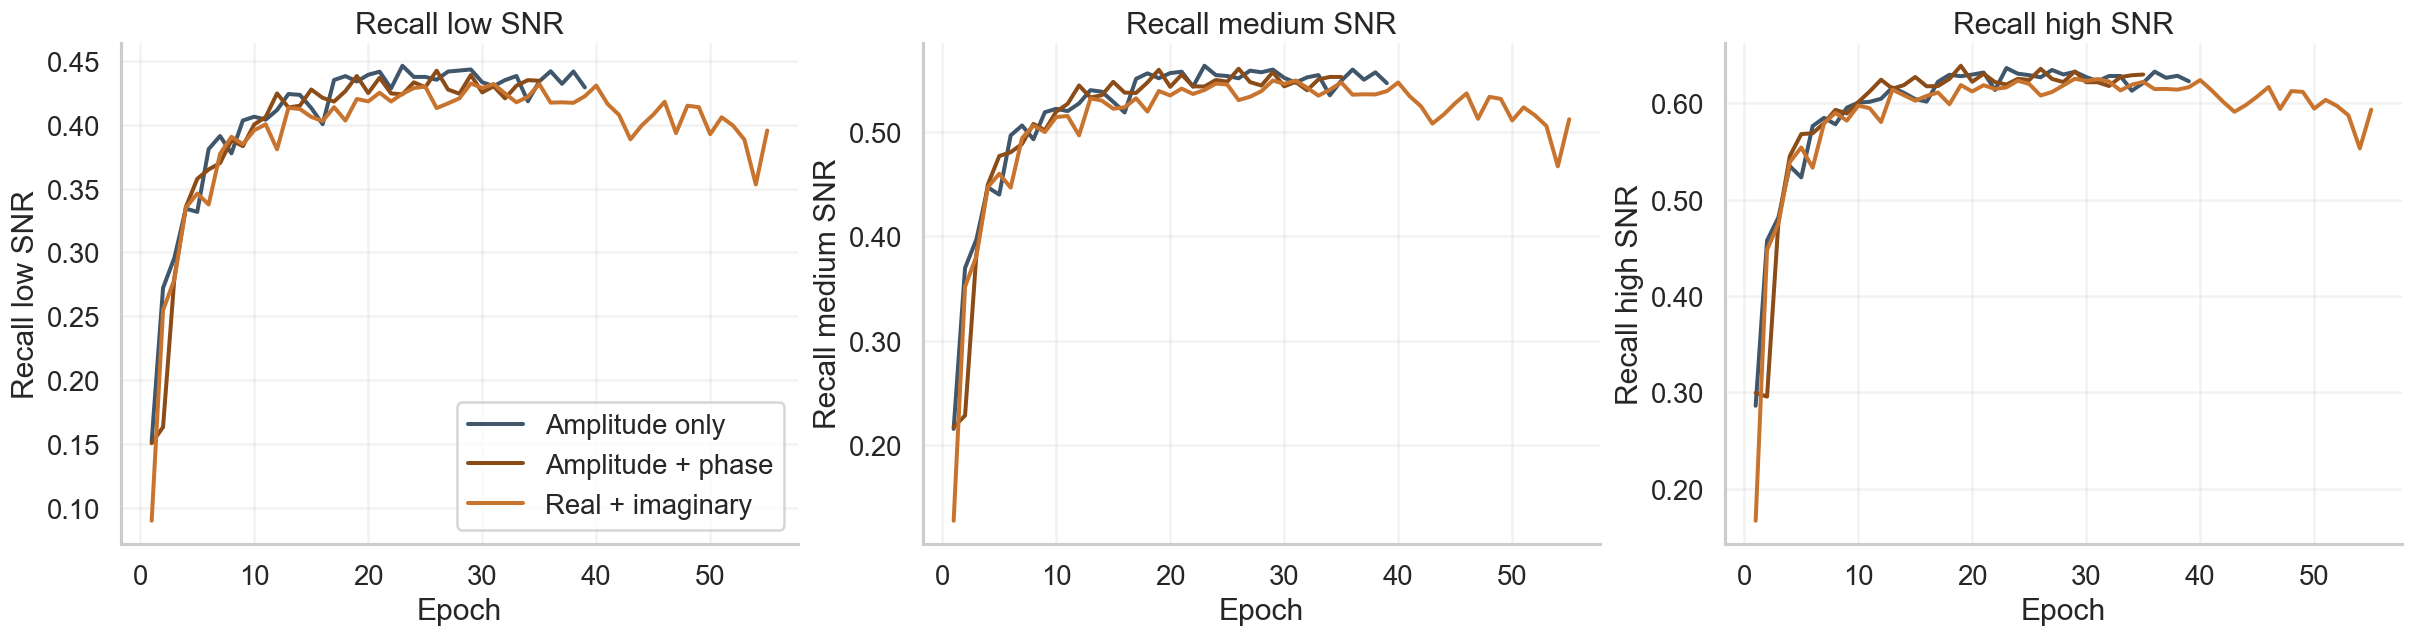

In [19]:
fig = plot_metric_grid(RUNS, ["map50", "map50_95"], ncols=2, save_stem="metric_grid_map")
plt.show()

fig = plot_metric_grid(RUNS, ["train_loss", "val_loss"], ncols=2, save_stem="metric_grid_loss")
plt.show()

fig = plot_metric_grid(
    RUNS,
    ["avg_recall_low_snr", "avg_recall_medium_snr", "avg_recall_high_snr"],
    ncols=3,
    figsize=(20, 5.2),
    save_stem="metric_grid_recall",
)
plt.show()


## Row-normalized confusion matrices

This figure keeps only the row-normalized confusion matrices for the three runs, without any `A - B` difference view.


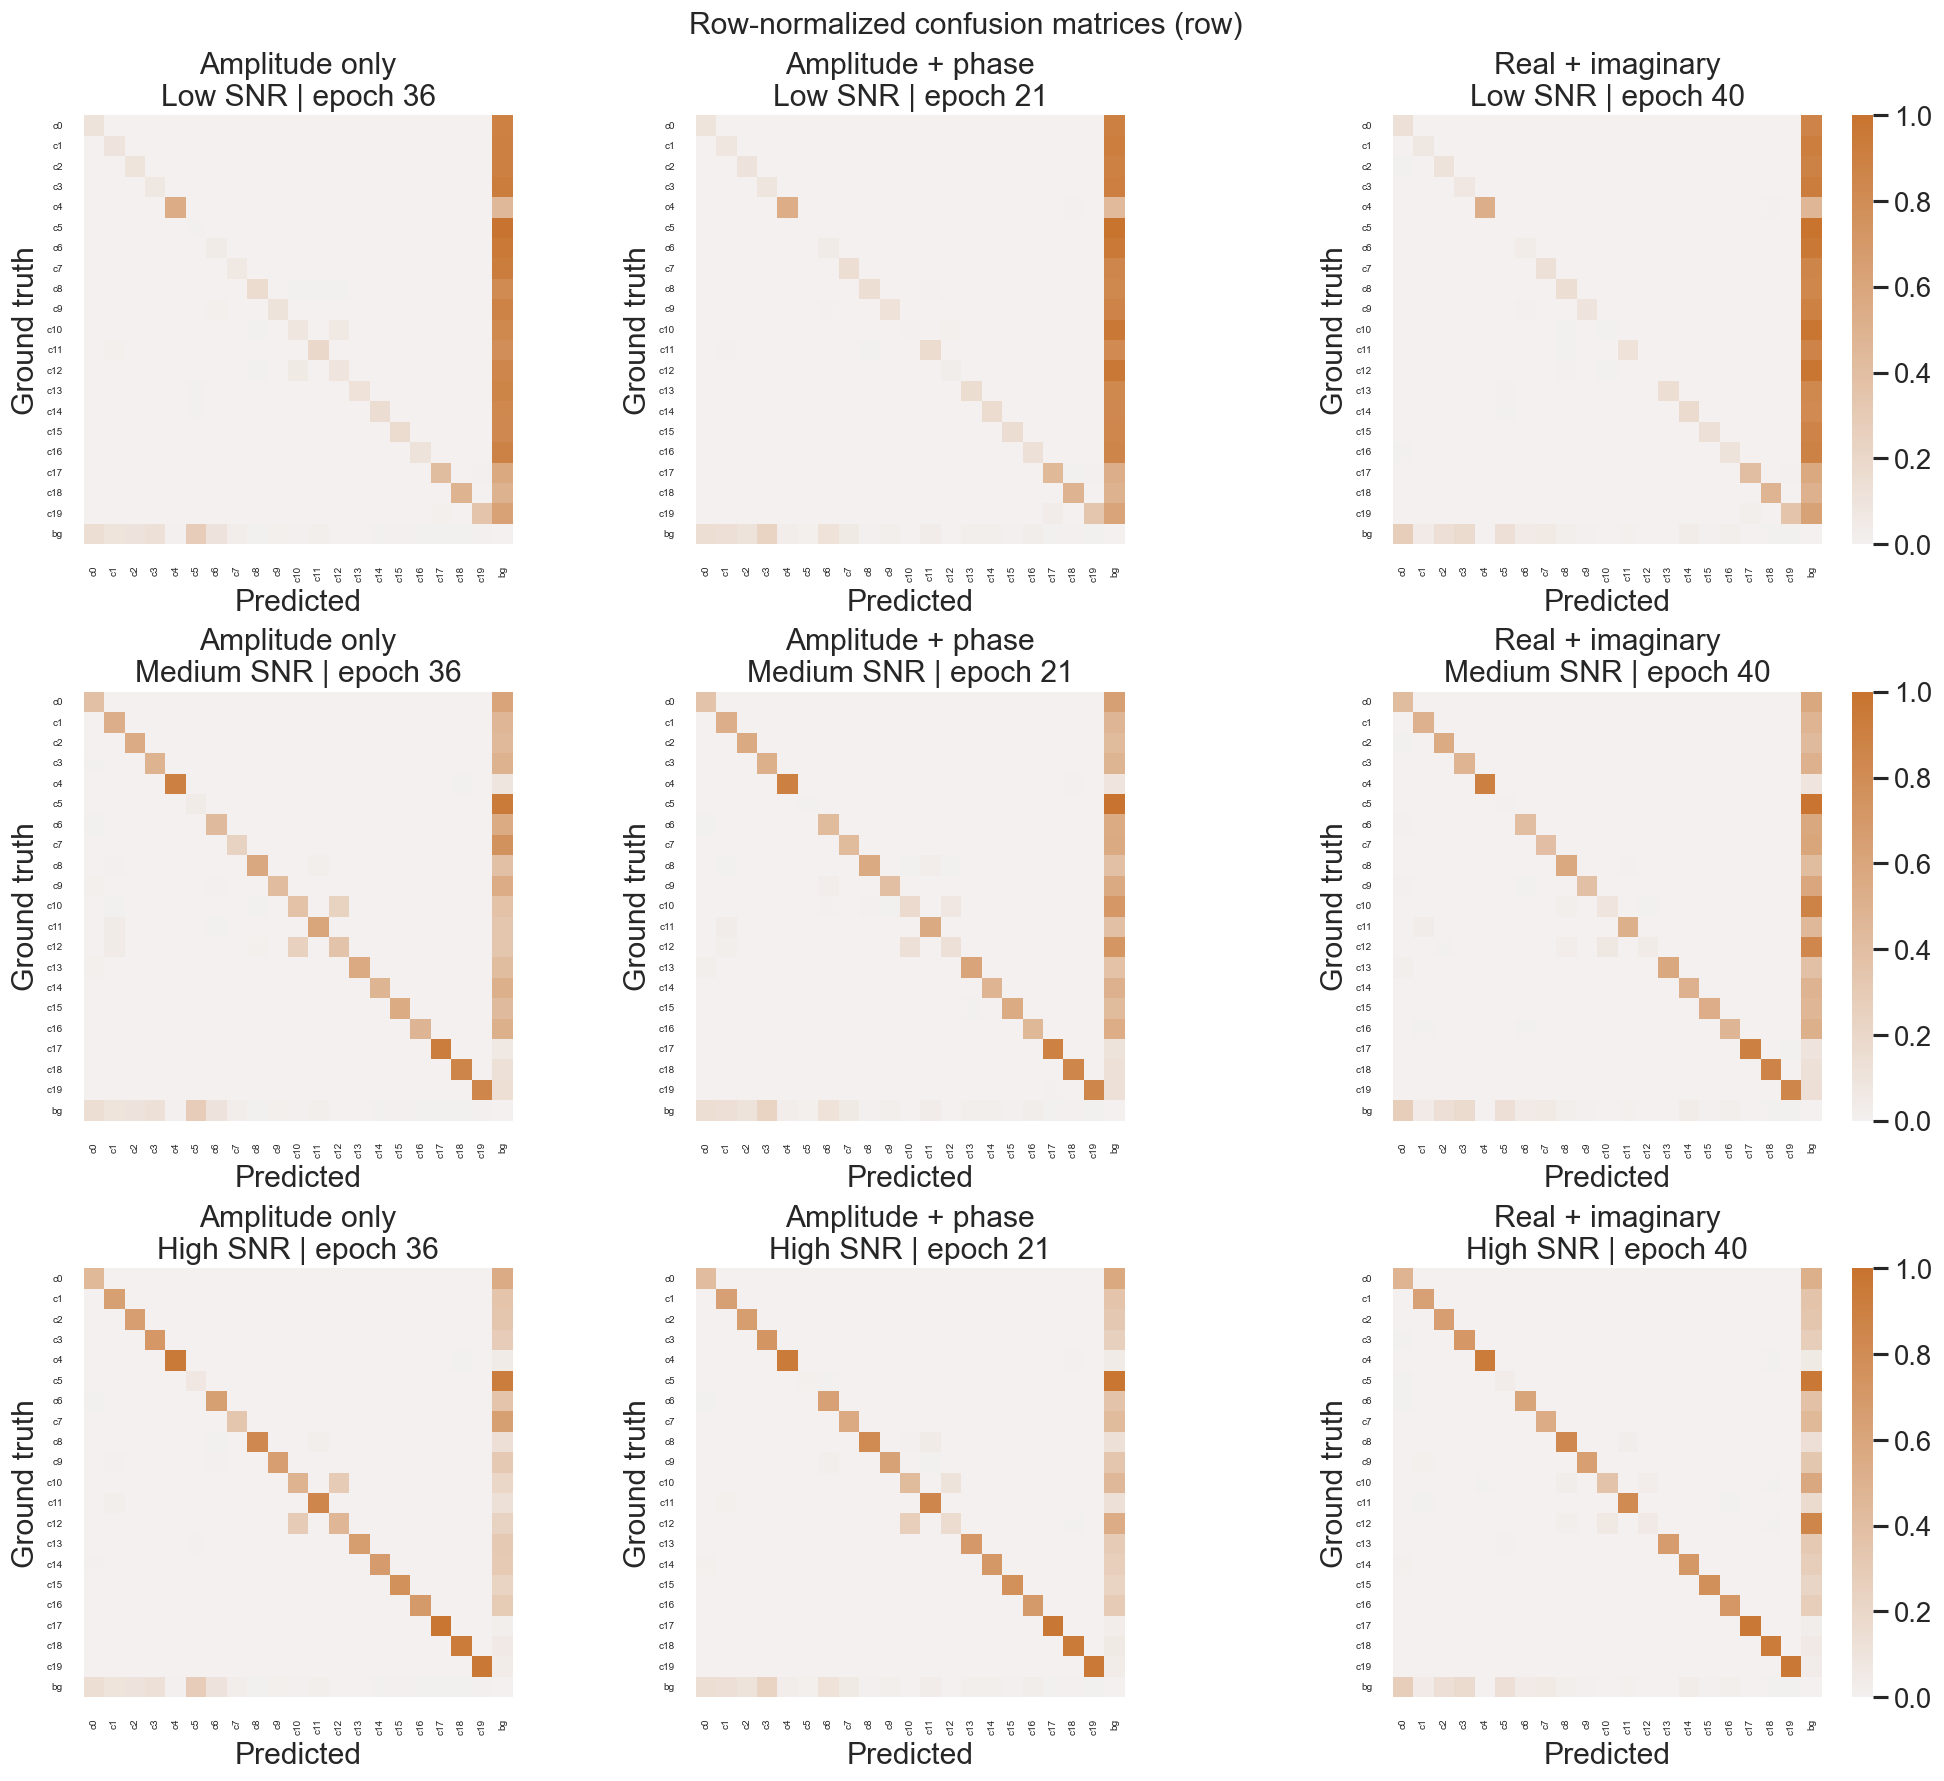

In [20]:
fig = plot_single_confusion_grid(RUNS, normalization="row")
plt.show()
